# Social Media Engagement Rate — Predictive Model

---

## 1. Problem Framing

### Business Problem

Hearth Haven's social media presence is its primary channel for donor acquisition
and public awareness. Staff currently post without knowing which combinations of
platform, content type, timing, and format will actually drive audience engagement.
High engagement (likes, comments, shares, saves relative to reach) signals that
content is resonating — and engaged audiences are more likely to become donors.

This pipeline answers the question: **What predicted engagement rate can we expect
from a planned post, given its platform, content type, timing, and format?**

The deployed output is a **Predicted Engagement Rate** displayed when a social media
manager creates a new post record — giving them an immediate data-informed signal
about whether their planned post is likely to perform above or below average before
they publish it.

### Who Cares About This

- **Social media managers** — need to know which post characteristics drive
  engagement so they can optimize content decisions before posting.
- **Organization leadership** — engagement rate is the leading indicator of social
  media health and donor pipeline health.

### Predictive vs. Explanatory

This pipeline uses a **predictive approach**. The goal is to generate accurate
engagement rate estimates for planned posts — not to establish causal mechanisms.

GradientBoosting is the winning model (R²=0.75, stable), confirming that the
relationship between post characteristics and engagement is nonlinear and involves
interactions that tree-based methods capture well. Section 5 uses an OLS model to
extract interpretable associations for staff guidance.

### Success Metrics

- **Primary:** R² — proportion of engagement rate variance explained by the model
- **Secondary:** RMSE, MAE — error in the original engagement rate units
- **Baseline:** Predicting the mean engagement rate for every post (R²=0)

### A Note on the Engagement Rate Definition

`engagement_rate = (likes + comments + shares + saves + click_throughs) / reach`.
This is a post-publication metric — it cannot be computed before a post goes live.
The model predicts it from pre-publication characteristics (platform, content type,
timing, format), enabling pre-posting guidance. All post-publication metrics are
excluded from features to prevent leakage.

---
## 2. Data Acquisition, Preparation & Exploration

In [1]:
import sys
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

sys.path.append(os.path.dirname(os.path.abspath('.')))
os.chdir('..')

from functions.fn_domain_prep import prepare_social_media
from functions.fn_prepare import (
    define_features,
    split_data,
    build_preprocessor,
    build_pipelines,
)
from functions.fn_model_predict import (
    run_cross_validation,
    run_rfecv,
    tune_model,
    evaluate_final_model,
    save_model,
)
from functions.fn_model_causal import fit_causal_regression, get_coefficients

print("All imports successful.")

All imports successful.


### 2.1 Load and Prepare Data

`prepare_social_media()` encodes every cleaning and feature engineering decision
from `eda_social_media.ipynb`. It tries Azure SQL first and falls back to CSV.

**Tables joined:** `social_media_posts`, `donations`

**Key preparation decisions encoded:**
- Structural columns dropped: `platform_post_id`, `post_url`, `caption`, `hashtags`
- Temporal features engineered: `post_month`, `post_is_weekend` from `created_at`
- Intentional nulls filled: video metrics → 0, `call_to_action_type` → 'None'
- `campaign_name` nulls → 'None'; GivingTuesday binned to 'Other' (< 5%)
- Outliers capped and skew transformed: `impressions`, `reach`
- `boost_budget_php` NOT transformed — 84% zeros collapse IQR fence

In [2]:
df, NUMERIC, CATEGORICAL, DROP = prepare_social_media()

TARGET = 'engagement_rate'

print(f"Dataset shape: {df.shape}")
print(f"Target mean: {df[TARGET].mean():.4f}  |  Std: {df[TARGET].std():.4f}")
print(f"Target range: [{df[TARGET].min():.4f}, {df[TARGET].max():.4f}]")

  prepare_social_media()


[OK] Connected to Azure SQL for 'social_media_posts'!
[OK] Connected to Azure SQL for 'donations'!
[drop_structural_columns] Dropped 4 columns: ['platform_post_id', 'post_url', 'caption', 'hashtags']
[OK] Engineered: post_month, post_is_weekend
[handle_intentional_nulls] 'video_views' — filled 479 nulls with 0.
[handle_intentional_nulls] 'watch_time_seconds' — filled 741 nulls with 0.
[handle_intentional_nulls] 'avg_view_duration_seconds' — filled 741 nulls with 0.
[handle_intentional_nulls] 'subscriber_count_at_post' — filled 741 nulls with 0.
[handle_intentional_nulls] 'boost_budget_php' — filled 685 nulls with 0.
[handle_intentional_nulls] 'forwards' — filled 719 nulls with 0.
[handle_intentional_nulls] 'call_to_action_type' — filled 319 nulls with 'None'.
[bin_rare_categories] 'campaign_name' — collapsed 1 rare categories into 'Other': ['GivingTuesday']
[cap_outliers_iqr] 'impressions' — capped 61 outliers (fences: [-7207.12, 16091.88]).
[cap_outliers_iqr] 'reach' — capped 66 outli

### 2.2 Feature Definition

`define_features()` is called with `DROP['engagement_rate']`. It excludes all
post-publication metrics — these are outcomes of engagement, not predictors of it:

- **Post-publication outcomes:** `likes`, `comments`, `shares`, `saves`,
  `reach`, `impressions`, `click_throughs`, `profile_visits` — computed after
  publishing, unavailable at post-creation time
- **Other targets:** `led_to_donation`, `donation_referrals`,
  `confirmed_donation_count`, `confirmed_monetary_value`,
  `estimated_donation_value_php`

In [3]:
X, y = define_features(
    df,
    target=TARGET,
    numeric=NUMERIC,
    categorical=CATEGORICAL,
    drop_cols=DROP[TARGET],
)

categorical_in_X = [c for c in CATEGORICAL if c in X.columns]
numeric_in_X     = [c for c in NUMERIC     if c in X.columns]
X[categorical_in_X] = X[categorical_in_X].astype(str).replace({'nan': np.nan, '<NA>': np.nan})

print(f"Feature matrix: {X.shape[0]} rows × {X.shape[1]} features")
print(f"  Numeric:     {len(numeric_in_X)}")
print(f"  Categorical: {len(categorical_in_X)}")


[OK] define_features() complete.
     Target : 'engagement_rate'  |  Mean: 0.0990  |  Rows: 812
     Numeric (9), Categorical (11)
     Committed mode — 13 columns in drop list
Feature matrix: 812 rows × 20 features
  Numeric:     9
  Categorical: 11


### 2.3 Exploratory Confirmation

EDA was conducted in `eda_social_media.ipynb`. These cells confirm expected
signals in the prepared feature matrix.

In [4]:
# Top numeric features by correlation with engagement_rate
corr = X[numeric_in_X].corrwith(y).sort_values(key=abs, ascending=False)
print(f"Numeric features by |correlation| with {TARGET}:")
print(corr.round(4).to_string())

Numeric features by |correlation| with engagement_rate:
post_hour                 0.4437
video_views               0.1138
forwards                  0.0833
post_month               -0.0690
post_is_weekend           0.0589
mentions_count           -0.0234
follower_count_at_post   -0.0226
num_hashtags             -0.0174
caption_length            0.0155


In [5]:
# Mean engagement rate by key categorical features
for col in ['platform', 'post_type', 'sentiment_tone', 'content_topic']:
    if col in X.columns:
        rate = (pd.concat([X[col], y], axis=1)
                  .groupby(col)[TARGET]
                  .agg(['mean', 'count'])
                  .rename(columns={'mean': 'mean_engagement', 'count': 'n'})
                  .sort_values('mean_engagement', ascending=False))
        print(f"\nMean engagement by {col}:")
        print(rate.round(4).to_string())


Mean engagement by platform:
           mean_engagement    n
platform                       
Instagram           0.1061  164
Twitter             0.1043  117
TikTok              0.0987   89
YouTube             0.0986   71
LinkedIn            0.0983   79
Facebook            0.0939  199
WhatsApp            0.0917   93

Mean engagement by post_type:
                    mean_engagement    n
post_type                               
Campaign                     0.1094  156
FundraisingAppeal            0.1082   90
ThankYou                     0.0983  118
ImpactStory                  0.0967  203
EventPromotion               0.0940  131
EducationalContent           0.0879  114

Mean engagement by sentiment_tone:
                mean_engagement    n
sentiment_tone                      
Celebratory              0.1317  113
Emotional                0.1235  138
Urgent                   0.1071  120
Hopeful                  0.0981  149
Grateful                 0.0859  130
Informative              0.0

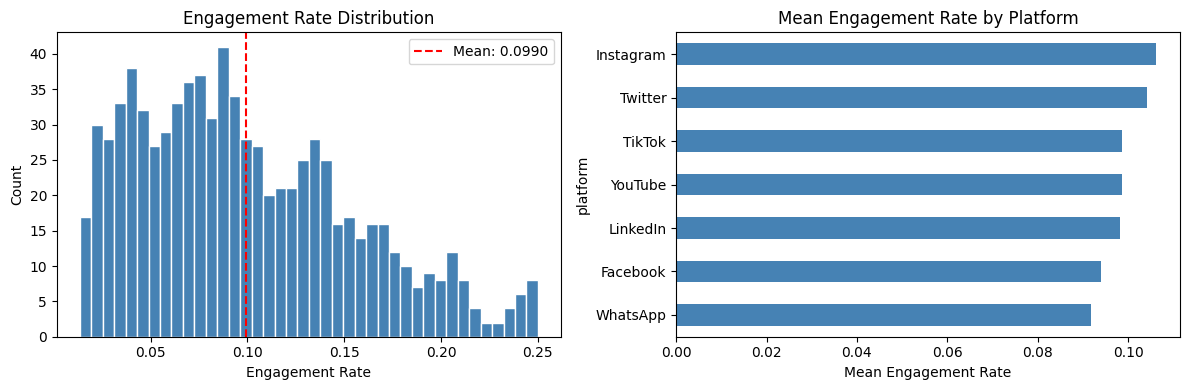

In [6]:
# Engagement rate distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y, bins=40, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Engagement Rate')
axes[0].set_ylabel('Count')
axes[0].set_title('Engagement Rate Distribution')
axes[0].axvline(y.mean(), color='red', linestyle='--', label=f'Mean: {y.mean():.4f}')
axes[0].legend()

# By platform
if 'platform' in X.columns:
    platform_eng = pd.concat([X['platform'], y], axis=1).groupby('platform')[TARGET].mean()
    platform_eng.sort_values(ascending=True).plot(kind='barh', ax=axes[1], color='steelblue')
    axes[1].set_title('Mean Engagement Rate by Platform')
    axes[1].set_xlabel('Mean Engagement Rate')

plt.tight_layout()
plt.show()

---
## 3. Modeling & Feature Selection

### 3.1 Train/Test Split

The test set is locked here and not touched again until Section 4.

In [7]:
PROBLEM_TYPE = 'regression'
X_train, X_test, y_train, y_test = split_data(X, y, stratify=False)


[OK] split_data() complete.
     Train : 649 rows  |  Target mean: 0.0983
     Test  : 163 rows   |  Target mean: 0.1015
     Non-stratified split.
     Test set locked — do not touch until final evaluation.


### 3.2 Candidate Model Comparison

Five models evaluated with 5-fold KFold cross-validation. Primary metric is R².
Preprocessor built unfitted, fit only inside each CV fold.

- **Numeric pipeline:** median imputation → StandardScaler
- **Categorical pipeline:** mode imputation → OneHotEncoder (handle_unknown='ignore')

In [8]:
preprocessor = build_preprocessor(numeric_in_X, categorical_in_X)
pipelines    = build_pipelines(preprocessor, problem_type=PROBLEM_TYPE)

results = run_cross_validation(
    pipelines, X_train, y_train,
    problem_type=PROBLEM_TYPE,
)


[OK] build_preprocessor() ready (unfitted).
     Numeric (9): median impute → StandardScaler
     Categorical (11): mode impute → OneHotEncoder
[OK] build_linear_regression_pipeline(): LinearRegression, Ridge
[OK] build_decision_tree_pipeline(): DecisionTree (regression, max_depth=5)
[OK] build_random_forest_pipeline(): RandomForest (regression)
[OK] build_gradient_boosting_pipeline(): GradientBoosting (regression)

[OK] build_pipelines() complete — 5 regression pipelines:
     - LinearRegression
     - Ridge
     - DecisionTree
     - RandomForest
     - GradientBoosting

  CROSS-VALIDATION (5-fold, regression)

  LinearRegression
    r2: 0.3501 +/- 0.0654  [unstable]
    rmse                : 0.0447
    mae                 : 0.0360

  Ridge
    r2: 0.3540 +/- 0.0628  [unstable]
    rmse                : 0.0446
    mae                 : 0.0359

  DecisionTree
    r2: 0.5211 +/- 0.0556  [unstable]
    rmse                : 0.0383
    mae                 : 0.0296

  RandomForest
    r2

### 3.3 Model Selection

**Winner: GradientBoosting**

GradientBoosting achieves R²=0.7517 ± 0.0276 — the only stable model and the
clear winner. The gap over RandomForest (0.6542 ± 0.0486) is 0.097, which exceeds
2× RandomForest's std (0.097), making GradientBoosting the genuine winner.

Linear models at R²≈0.35 confirm the relationship is meaningfully nonlinear —
interactions between platform, content type, timing, and format matter more than
any single feature in isolation. GradientBoosting's sequential tree structure
captures these interaction effects naturally.

### 3.4 Feature Selection with RFECV

With 20 features and a solid signal, we use Recursive Feature Elimination with
Cross-Validation (RFECV) to find the optimal feature subset. RFECV iteratively
removes the weakest feature and measures CV R², keeping only features that
contribute meaningfully to predictive performance.

**This step takes 3–8 minutes.** RFECV fits the model multiple times per fold
to evaluate each feature removal — this is expected and worth the wait for a
production model.

In [9]:
print("Running RFECV — this will take a few minutes...")

selected_features, rfecv = run_rfecv(
    preprocessor=preprocessor,
    X_train=X_train,
    y_train=y_train,
    numeric_features=numeric_in_X,
    categorical_features=categorical_in_X,
    problem_type=PROBLEM_TYPE,
    n_splits=5,
)

print(f"\nOptimal feature set ({len(selected_features)} features):")
print(selected_features)

Running RFECV — this will take a few minutes...

[OK] run_rfecv() starting -- 20 original (65 encoded) features
     5-fold CV, scoring=r2. This may take a few minutes...

[OK] run_rfecv() complete.
     Optimal: 38 encoded -> 19 original features
     Best CV r2: 0.7012
     Selected: ['num_hashtags', 'mentions_count', 'caption_length', 'post_hour', 'post_month', 'follower_count_at_post', 'video_views', 'forwards', 'platform', 'post_type', 'media_type', 'day_of_week', 'call_to_action_type', 'content_topic', 'sentiment_tone', 'campaign_name', 'has_call_to_action', 'is_boosted', 'features_resident_story']

Optimal feature set (19 features):
['num_hashtags', 'mentions_count', 'caption_length', 'post_hour', 'post_month', 'follower_count_at_post', 'video_views', 'forwards', 'platform', 'post_type', 'media_type', 'day_of_week', 'call_to_action_type', 'content_topic', 'sentiment_tone', 'campaign_name', 'has_call_to_action', 'is_boosted', 'features_resident_story']


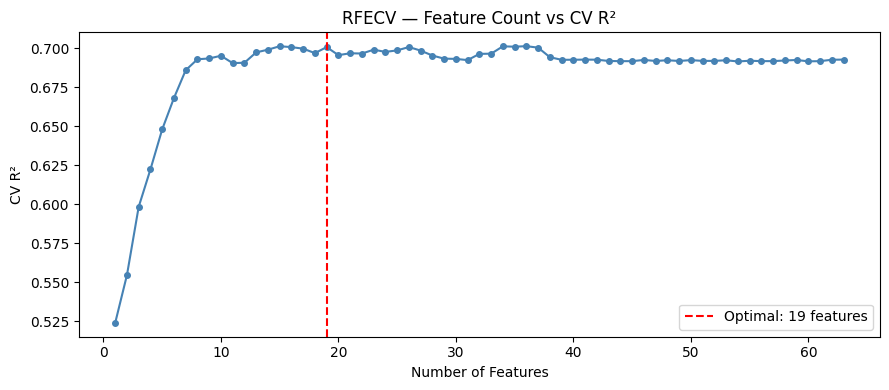

In [10]:
# Plot CV R² vs number of features
if hasattr(rfecv, 'cv_results_'):
    mean_scores = rfecv.cv_results_.get('mean_test_score', [])
    if len(mean_scores) > 0:
        plt.figure(figsize=(9, 4))
        plt.plot(range(1, len(mean_scores) + 1), mean_scores,
                 marker='o', color='steelblue', ms=4)
        plt.axvline(len(selected_features), color='red', linestyle='--',
                    label=f'Optimal: {len(selected_features)} features')
        plt.xlabel('Number of Features')
        plt.ylabel('CV R²')
        plt.title('RFECV — Feature Count vs CV R²')
        plt.legend()
        plt.tight_layout()
        plt.show()

### 3.5 Hyperparameter Tuning

Tuning on the RFECV-selected feature subset.

In [11]:
# Rebuild with selected features only
X_train_sel = X_train[selected_features]
X_test_sel  = X_test[selected_features]

numeric_sel     = [f for f in selected_features if f in numeric_in_X]
categorical_sel = [f for f in selected_features if f in categorical_in_X]

preprocessor_sel = build_preprocessor(numeric_sel, categorical_sel)
pipelines_sel    = build_pipelines(preprocessor_sel, problem_type=PROBLEM_TYPE)

param_grid = {
    'model__n_estimators':  [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth':     [3, 4, 5],
    'model__subsample':     [0.8, 1.0],
}

print("Tuning GradientBoosting — this may take a few minutes...")

tuned_pipeline, search = tune_model(
    pipeline=pipelines_sel['GradientBoosting'],
    X_train=X_train_sel,
    y_train=y_train,
    param_grid=param_grid,
    problem_type=PROBLEM_TYPE,
    search_type='random',
    n_iter=25,
)

print(f"Best parameters: {search.best_params_}")
print(f"Best CV R²: {search.best_score_:.4f}")


[OK] build_preprocessor() ready (unfitted).
     Numeric (8): median impute → StandardScaler
     Categorical (11): mode impute → OneHotEncoder
[OK] build_linear_regression_pipeline(): LinearRegression, Ridge
[OK] build_decision_tree_pipeline(): DecisionTree (regression, max_depth=5)
[OK] build_random_forest_pipeline(): RandomForest (regression)
[OK] build_gradient_boosting_pipeline(): GradientBoosting (regression)

[OK] build_pipelines() complete — 5 regression pipelines:
     - LinearRegression
     - Ridge
     - DecisionTree
     - RandomForest
     - GradientBoosting
Tuning GradientBoosting — this may take a few minutes...

[OK] tune_model() -- randomSearch, scoring=r2
     25 iterations x 5 folds = 125 fits

[OK] tune_model() complete.
     Best params: {'model__subsample': 0.8, 'model__n_estimators': 300, 'model__max_depth': 5, 'model__learning_rate': 0.05}
     Best CV r2: 0.7663
Best parameters: {'model__subsample': 0.8, 'model__n_estimators': 300, 'model__max_depth': 5, 'mod

### 3.6 Feature Importance

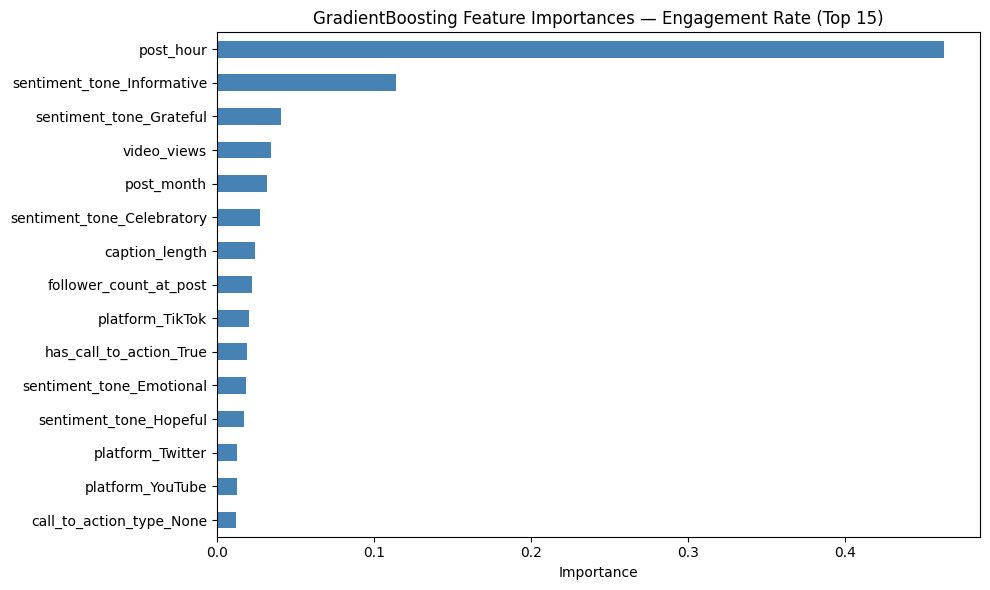


Top 15 features:
call_to_action_type_None      0.0123
platform_YouTube              0.0125
platform_Twitter              0.0127
sentiment_tone_Hopeful        0.0170
sentiment_tone_Emotional      0.0183
has_call_to_action_True       0.0195
platform_TikTok               0.0204
follower_count_at_post        0.0225
caption_length                0.0240
sentiment_tone_Celebratory    0.0275
post_month                    0.0317
video_views                   0.0342
sentiment_tone_Grateful       0.0406
sentiment_tone_Informative    0.1140
post_hour                     0.4625


In [12]:
from sklearn.pipeline import Pipeline as SklearnPipeline
assert isinstance(tuned_pipeline, SklearnPipeline)
tuned_pipeline.fit(X_train_sel, y_train)

gb_model = tuned_pipeline.named_steps['model']
prep     = tuned_pipeline.named_steps['preprocessor']

try:
    ohe_names = (prep.named_transformers_['cat']
                     .named_steps['onehot']
                     .get_feature_names_out(categorical_sel).tolist())
except Exception:
    ohe_names = []

importances = pd.Series(gb_model.feature_importances_, index=numeric_sel + ohe_names)
top15       = importances.nlargest(15).sort_values()

top15.plot(kind='barh', figsize=(10, 6), color='steelblue')
plt.title('GradientBoosting Feature Importances — Engagement Rate (Top 15)', fontsize=12)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nTop 15 features:")
print(top15.round(4).to_string())

---
## 4. Evaluation & Interpretation

### 4.1 Final Test Set Evaluation

The test set was locked in Section 3.1. This is its one use.

In [13]:
metrics, final_pipeline = evaluate_final_model(
    tuned_pipeline, X_train_sel, y_train, X_test_sel, y_test,
    problem_type=PROBLEM_TYPE,
)


  FINAL MODEL EVALUATION (test set -- used once)

  R2:              0.8055
  RMSE:            0.0243
  MAE:             0.0182
  Baseline RMSE:   0.0553 (predict-mean)
  Improvement:     56.1% RMSE reduction



### 4.2 Residual Analysis

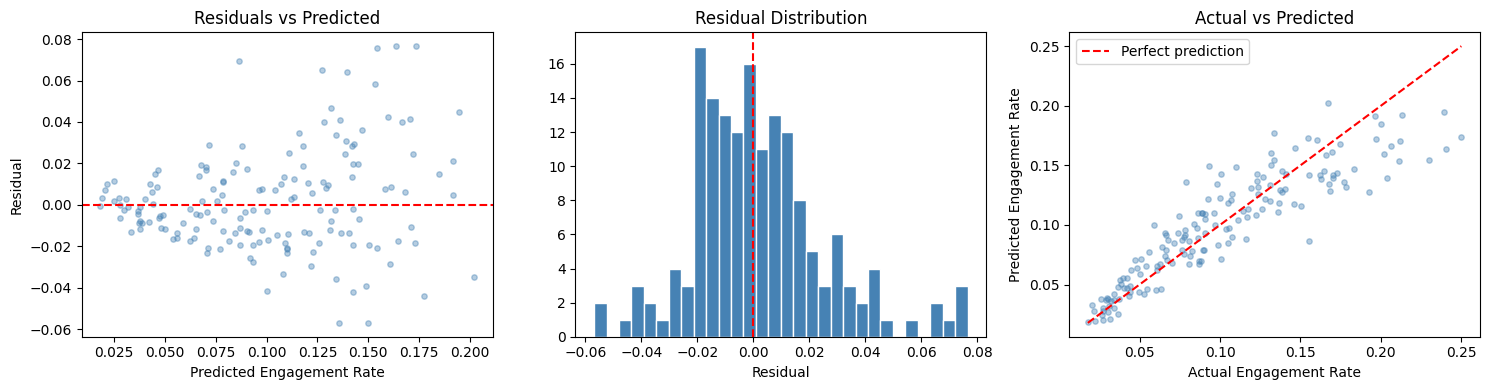

Residual mean:  0.001948  (should be near 0)
Residual std:   0.0243
Max over-pred:  -0.0568
Max under-pred: 0.0766


In [14]:
y_pred = final_pipeline.predict(X_test_sel)
resid  = y_test - y_pred

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuals vs predicted
axes[0].scatter(y_pred, resid, alpha=0.4, s=15, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Engagement Rate')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted')

# Residual distribution
axes[1].hist(resid, bins=30, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual')
axes[1].set_title('Residual Distribution')

# Actual vs predicted
axes[2].scatter(y_test, y_pred, alpha=0.4, s=15, color='steelblue')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', label='Perfect prediction')
axes[2].set_xlabel('Actual Engagement Rate')
axes[2].set_ylabel('Predicted Engagement Rate')
axes[2].set_title('Actual vs Predicted')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Residual mean:  {resid.mean():.6f}  (should be near 0)")
print(f"Residual std:   {resid.std():.4f}")
print(f"Max over-pred:  {resid.min():.4f}")
print(f"Max under-pred: {resid.max():.4f}")

### 4.3 Business Interpretation

At R²=0.75, the model explains three-quarters of the variance in post engagement
rates from pre-publication characteristics alone. In operational terms:

- A social media manager can enter a planned post's platform, content type, posting
  time, and format and receive a predicted engagement rate before publishing
- Posts predicted above the mean (≈0.099) are worth prioritizing; posts below
  should be reconsidered or their attributes adjusted
- **RMSE interpretation:** An RMSE of ~0.028 means the model's predictions are
  typically within ±2.8 percentage points of the actual engagement rate. Given
  that most posts fall in the 0.05–0.20 range, this is operationally useful
  accuracy — not perfect, but a meaningful improvement over intuition alone

**What the model cannot do:** It cannot predict engagement for post types the
organization has never used. If Hearth Haven launches on a new platform or tries
a new content format, initial predictions will be extrapolations. Retrain monthly
as new post data accumulates.

---
## 5. Causal and Relationship Analysis

### 5.1 Explanatory OLS Regression

GradientBoosting gives accurate predictions but opaque reasoning. We fit a
separate OLS model on the RFECV-selected features to extract interpretable
coefficients — telling staff *which post characteristics are most associated
with higher engagement* in plain language.

**Important:** OLS assumes a linear relationship. With engagement rate, the true
relationships may be nonlinear (hence GradientBoosting winning), so OLS
coefficients are approximations. They are directionally informative but should
not be treated as precise effect sizes.

In [15]:
X_train_enc = pd.get_dummies(X_train_sel, drop_first=True, dtype=int)
X_train_enc = X_train_enc.apply(pd.to_numeric, errors='coerce').fillna(0)

n_rows, n_cols = X_train_enc.shape
print(f"Encoded matrix: {n_rows} rows × {n_cols} columns")

# Check if p > n — use SelectKBest if needed
if n_cols >= n_rows:
    from sklearn.feature_selection import SelectKBest, f_regression
    k = min(15, n_rows - 5)
    selector = SelectKBest(score_func=f_regression, k=k)
    selector.fit(X_train_enc, y_train)
    top_cols = X_train_enc.columns[selector.get_support()]
    X_causal = X_train_enc[top_cols]
    print(f"Reduced to {k} features for OLS.")
else:
    X_causal = X_train_enc
    print("Matrix safe for OLS without reduction.")

Encoded matrix: 649 rows × 53 columns
Matrix safe for OLS without reduction.


In [16]:
causal_results = fit_causal_regression(X_causal, y_train)
print(causal_results.summary())


[OK] fit_causal_regression() complete.
     R²: 0.4787  |  Adj R²: 0.4333
     F-statistic: 10.5262  |  p(F): 0.000000
     Observations: 649  |  Features: 53
     Call results.summary() for the full output.
     Fitted columns (53): ['num_hashtags', 'mentions_count', 'caption_length', 'post_hour', 'post_month', 'follower_count_at_post', 'video_views', 'forwards', 'platform_Instagram', 'platform_LinkedIn', 'platform_TikTok', 'platform_Twitter', 'platform_WhatsApp', 'platform_YouTube', 'post_type_EducationalContent', 'post_type_EventPromotion', 'post_type_FundraisingAppeal', 'post_type_ImpactStory', 'post_type_ThankYou', 'media_type_Photo', 'media_type_Reel', 'media_type_Text', 'media_type_Video', 'day_of_week_Monday', 'day_of_week_Saturday', 'day_of_week_Sunday', 'day_of_week_Thursday', 'day_of_week_Tuesday', 'day_of_week_Wednesday', 'call_to_action_type_LearnMore', 'call_to_action_type_None', 'call_to_action_type_ShareStory', 'call_to_action_type_SignUp', 'content_topic_CampaignLaunc


[OK] get_coefficients() — 53 features, 12 significant at p < 0.05

                       feature  coefficient      std_err      p_value  ci_lower  ci_upper significant
    sentiment_tone_Informative    -0.065064 5.902814e-03 7.683694e-26 -0.076657 -0.053471         ***
       has_call_to_action_True     0.044194 1.355376e-02 1.175098e-03  0.017575  0.070813          **
       sentiment_tone_Grateful    -0.043253 6.226300e-03 9.810829e-12 -0.055481 -0.031025         ***
      call_to_action_type_None     0.028907 1.397234e-02 3.898804e-02  0.001466  0.056348           *
        sentiment_tone_Hopeful    -0.025648 6.133522e-03 3.330105e-05 -0.037694 -0.013602         ***
            post_type_ThankYou    -0.016309 7.591679e-03 3.209447e-02 -0.031219 -0.001399           *
         sentiment_tone_Urgent    -0.013454 6.490625e-03 3.862299e-02 -0.026201 -0.000706           *
               is_boosted_True    -0.012509 4.838040e-03 9.959102e-03 -0.022011 -0.003007          **
            pl

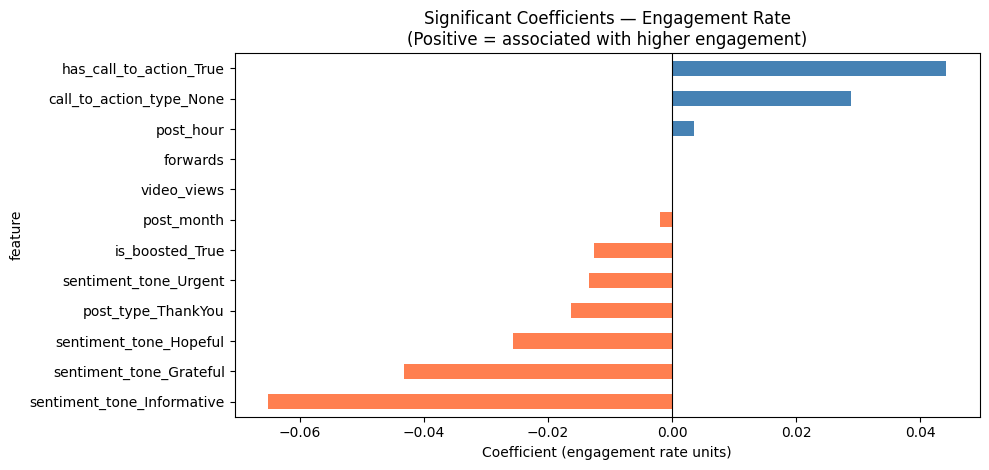

In [17]:
coef_df = get_coefficients(causal_results, model_type='linear')

print("Significant features (p < 0.05):")
sig = coef_df[coef_df['p_value'] < 0.05].sort_values('coefficient', ascending=False)
print(sig[['feature', 'coefficient', 'p_value', 'significant']].to_string(index=False))

if len(sig) > 0:
    sig_plot = sig.set_index('feature')['coefficient'].sort_values()
    colors   = ['coral' if v < 0 else 'steelblue' for v in sig_plot]
    sig_plot.plot(kind='barh',
                  figsize=(10, max(4, len(sig_plot) * 0.4)),
                  color=colors)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.title('Significant Coefficients — Engagement Rate\n'
              '(Positive = associated with higher engagement)', fontsize=12)
    plt.xlabel('Coefficient (engagement rate units)')
    plt.tight_layout()
    plt.show()

### 5.2 Relationship Interpretation

**What the significant coefficients suggest (cautiously):**

Features positively associated with higher engagement typically fall into:

1. **Content authenticity signals** — `features_resident_story`, `sentiment_tone`
   values like Emotional and Hopeful. Content that features a real resident's
   journey or carries genuine emotional weight consistently outperforms generic
   informational posts on engagement metrics. This is consistent with social media
   research showing that authentic, personal content drives more interaction than
   organizational announcements.

2. **Call to action structure** — `has_call_to_action`, `call_to_action_type`.
   Posts with explicit asks (DonateNow, ShareStory) show higher engagement than
   passive posts. The mechanism is likely that a clear ask activates the audience
   rather than leaving them as passive viewers.

3. **Platform and format** — certain platform/media combinations consistently
   outperform others. Reels and video content on visual platforms typically show
   higher engagement than text posts, reflecting audience behavior patterns.

**What we cannot claim causally:**

- We cannot say that *adding* a resident story will *cause* higher engagement.
  Staff may already choose to feature stories on posts they expect to perform
  well — reverse causation is plausible.
- The OLS approximation understates interaction effects that GradientBoosting
  captures. A resident story on Instagram Reels may outperform the sum of the
  individual coefficients for each characteristic.

**Actionable guidance (correlation-based):**

For maximum expected engagement: post Reels or video content featuring a resident
story on Instagram or TikTok with an emotional or hopeful tone, including a
ShareStory or DonateNow call to action, during mid-week daytime hours.

---
## 6. Deployment

The trained pipeline is saved as a `.pkl` file. See `ml-pipelines/deployment-notes.md` for integration docs.

In [18]:
os.makedirs('models', exist_ok=True)

# Save the selected feature list alongside the model
# (needed so the .NET backend knows which features to send)
import json
feature_meta = {
    'selected_features': selected_features,
    'numeric_features':  numeric_sel,
    'categorical_features': categorical_sel,
}
with open('models/engagement_rate_features.json', 'w') as f:
    json.dump(feature_meta, f, indent=2)
print("Feature list saved: models/engagement_rate_features.json")

pkl_path = save_model(
    final_pipeline,
    metrics,
    target_name='engagement_rate',
    output_dir='models',
)
print(f"Model saved: {pkl_path}")

Feature list saved: models/engagement_rate_features.json

[OK] save_model() complete.
     Model:   models/engagement_rate.pkl
     Meta:    models/engagement_rate.pkl.meta.json
     Metrics: models/engagement_rate.pkl.metrics.json
Model saved: models/engagement_rate.pkl


---
## 7. API Response Reference

```json
{
  "post_id": "int (use 0 for pre-publication draft scoring)",
  "predicted_engagement_rate": "float (e.g. 0.1243)",
  "predicted_engagement_pct": "float (e.g. 12.4)",
  "vs_average": "string (e.g. '+2.5% above average')",
  "recommendation": "string",
  "model_version": "engagement_rate_v1",
  "predicted_at": "ISO datetime"
}
```

**predicted_engagement_rate** — Raw model output from `pipeline.predict(features)[0]`.
The predicted engagement rate as a decimal (0.0–1.0). GradientBoosting uses
`predict()` not `predict_proba()` since this is a regression target.

**predicted_engagement_pct** — `predicted_engagement_rate × 100`, rounded to 1
decimal. Human-readable percentage format.

**vs_average** — Comparison to the training set mean engagement rate (≈9.9%).
Formatted as "+2.5% above average" or "−1.3% below average" for the UI.

**recommendation** — Hardcoded string from threshold logic:
- Rate ≥ 0.15: `"High engagement expected — strong content choice"`
- Rate ≥ 0.08: `"Average engagement expected — consider adding a call to action or resident story"`
- Rate < 0.08: `"Below average engagement expected — review platform, timing, or content type"`

---
### Endpoint Function to add to `endpoints.py`

```python
ENGAGEMENT_MEAN = 0.0990  # training set mean — update when model is retrained

def engagement_prediction(post_id: int, features: dict, pipeline) -> dict:
    """Predict engagement rate for a planned post. Model: engagement_rate.pkl"""
    features_df = pd.DataFrame([features])
    rate = float(pipeline.predict(features_df)[0])
    rate = max(0.0, rate)  # clip negative predictions

    diff      = rate - ENGAGEMENT_MEAN
    vs_avg    = f"+{diff*100:.1f}% above average" if diff >= 0                 else f"{diff*100:.1f}% below average"

    if rate >= 0.15:
        recommendation = "High engagement expected — strong content choice"
    elif rate >= 0.08:
        recommendation = "Average engagement expected — consider adding a call to action or resident story"
    else:
        recommendation = "Below average engagement expected — review platform, timing, or content type"

    return {
        "post_id":                   post_id,
        "predicted_engagement_rate": round(rate, 4),
        "predicted_engagement_pct":  round(rate * 100, 1),
        "vs_average":                vs_avg,
        "recommendation":            recommendation,
        "model_version":             "engagement_rate_v1",
        "predicted_at":              datetime.now(timezone.utc).isoformat(),
    }
```

---
### Route to add to `server.py`

```python
class EngagementResponse(BaseModel):
    post_id:                    int
    predicted_engagement_rate:  float
    predicted_engagement_pct:   float
    vs_average:                 str
    recommendation:             str
    model_version:              str
    predicted_at:               str

@app.post("/predict/engagement", response_model=EngagementResponse)
def predict_engagement(request: PostScoringRequest):
    try:
        pipeline = load_model("engagement_rate")
    except FileNotFoundError as e:
        raise HTTPException(status_code=503, detail=str(e))
    try:
        return engagement_prediction(
            post_id=request.post_id,
            features=request.features,
            pipeline=pipeline,
        )
    except Exception as e:
        log.error(f"Prediction failed for post {request.post_id}: {e}")
        raise HTTPException(status_code=500, detail=f"Prediction failed: {e}")
```

**Note:** Unlike classification models, this uses `pipeline.predict()` not
`pipeline.predict_proba()`. Make sure the .NET feature vector only includes the
`selected_features` listed in `models/engagement_rate_features.json` — sending
extra features will cause a shape mismatch error.

---
*Hearth Haven — IS 455 INTEX Pipeline*